In [ ]:
# Confirm that JSBSim is installed. If not and running on Google Colab
# then install JSBSim into the Google Colab instance.

import os
from pathlib import Path

try:
  import jsbsim
  print('JSBSim is installed')
  # Relative path to the directory where the flight model is stored
  # Note - Aircraft directory needs to be writeable in order to modify the cg
  PATH_TO_JSBSIM_FILES= str(Path.cwd().parent.parent.parent / "jsbsim")
  print(f'Current working directory: {os.getcwd()}')
except ImportError:
  import sys
  if 'google.colab' in sys.modules:
      print('Installing JSBSim...')
      %pip install jsbsim
      # Use the standard aircraft supplied by the JSBSim Python package
      PATH_TO_JSBSIM_FILES=None

JSBSim is installed
Current working directory: /home/robotzgold/Documents/robotfiles/reposGit/jsbsim/examples/python


In [10]:
import matplotlib.pyplot as plt
import math
# --- Configuration Section ---
# Global variables that must be modified to match your particular need
# The aircraft name
# Note - It should match the exact spelling of the model file
AIRCRAFT_NAME="A4"

# --- JSBSim Initialization ---
# These lines initialize the flight dynamics model.

# Avoid flooding the console with log messages
jsbsim.FGJSBBase().debug_lvl = 0

# Create a flight dynamics model (FDM) instance.
# path: from jsbsim models 
fdm = jsbsim.FGFDMExec(PATH_TO_JSBSIM_FILES)

# Load the aircraft model
fdm.load_model(AIRCRAFT_NAME)

# Set engines running
fdm['propulsion/engine[0]/throttle-cmd-norm'] = 0.5  # 50% throttle
fdm['propulsion/engine[0]/set-running'] = 1 # always motor running?

# Get the simulation time step (delta time).
dt = fdm.get_delta_t()

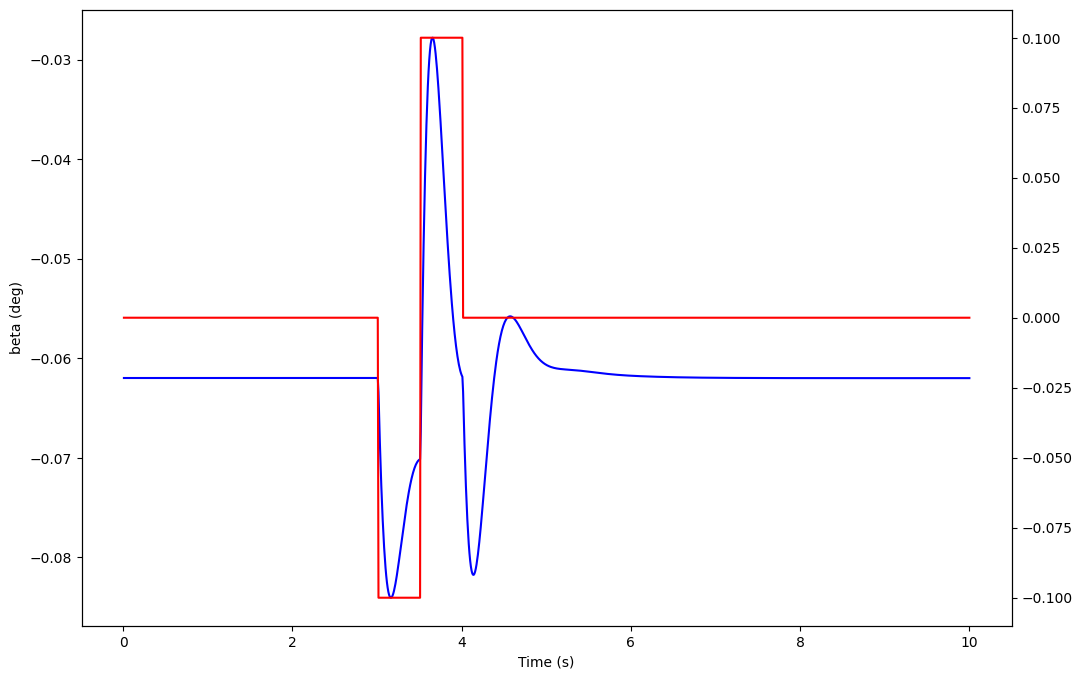

In [11]:
# --- Data Storage ---
# This section initializes lists to record simulation data.

times = []      # List to record the simulation time at each step.
altitudes = []      # List to record the beta angle at each step.
airspeed = []  # List to record the bank angle at each step.
ailerons = []   # List to record the aileron control surface deflection.
elevator_pos = []
elevator_commands = []
pitchRate = []

# --- Simulation Initialization ---
# This line initializes the flight dynamics model.

# Initial conditions
fdm['ic/h-sl-ft'] = 8000  #altitude above sea level (ft)
fdm['ic/vt-kts'] = 250    #calibrated airspeed (kts)
fdm['ic/gamma-deg'] = 0   #flight path angle (deg)
fdm['ic/beta-deg'] = 0    #sideslip angle (deg)

# Initialize the aircraft with initial conditions
fdm.run_ic()

# Attempt to trim the aircraft.
try:
    # 1 means straight flight by using all changeable control variables.
    fdm['simulation/do_simple_trim'] = 1

except jsbsim.TrimFailureError:
    print("Trim failed, continuing rudder kick in an untrimmed state.")
    pass  # Ignore trim failure

# --- Simulation Loop ---
# This is the main simulation loop that runs the simulation for a specified duration.

# Time to run for in seconds.
run_period = 10

# Start the doublet 2 seconds into the simulation to ensure we are in a steady trim.
doublet_start_time = 3.0  
sas_start_time = 2.5
doublet_width = 0.5       # Duration of each pulse in seconds.
doublet_amplitude = 0.1   # Magnitude of the elevator deflection (normalized -1 to 1).

for i in range(int(run_period/dt)):
    # Advance the simulation by one time step.
    fdm.run()
    
    # Record the simulation data.
    times.append(fdm.get_sim_time())
    altitudes.append(fdm['position/h-sl-ft'])  
    airspeed.append(fdm['velocities/vc-kts'])
    pitchRate.append(fdm['velocities/q-rad_sec']) 
    elevator_commands.append(fdm['fcs/elevator-cmd-norm'])
    elevator_pos.append(fdm['fcs/elevator-pos-rad'])
    
    fdm['fcs/sas-active-switch'] = 1
    # 2. Get the current simulation time to determine which part of the doublet we are in.
    current_time = fdm.get_sim_time()

    # 3. Doublet Logic: We define three distinct phases.
    # Phase A: The first "up" pulse (positive pitch/negative elevator).
    if doublet_start_time <= current_time < (doublet_start_time + doublet_width):
        elevator_cmd = -doublet_amplitude  # Typical "pull" for pitch up.

    # Phase B: The second "down" pulse (immediate reversal).
    elif (doublet_start_time + doublet_width) <= current_time < (doublet_start_time + 2 * doublet_width):
        elevator_cmd = doublet_amplitude   # Typical "push" for pitch down.

    # Phase C: Return to neutral (trim) to observe the natural damping of the aircraft.
    else:
        elevator_cmd = 0.0

    # 4. Apply the command to the elevator property.
    # JSBSim uses 'fcs/elevator-cmd-norm' as the standard input for elevator control.
    
    fdm['fcs/elevator-cmd-norm'] = elevator_cmd 
    
   
# --- Plot Results ---
# This section plots the simulation results.

plt.rcParams["figure.figsize"] = (12, 8) # Set the figure size.
fig, ax1 = plt.subplots()

# Plot the beta data on the primary y-axis.
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('beta (deg)')
#ax1.set_ylim(0,150)
#line1 = ax1.plot(times, airspeed, label='airspeed', color='red')

line1 = ax1.plot(times, elevator_pos, label='pitchRate', color='blue')
ax2 = ax1.twinx()
line1 = ax2.plot(times, elevator_commands, label='pitchRate', color='red')
# Create a secondary y-axis for the control surface positions.

# Display the plot.
plt.show()